# YOLOX Proof-of-Concept Experiment for ADAS Perception (Simple Version)

This notebook keeps the YOLOX setup as simple as possible. It clones the official YOLOX repository, installs the missing packages, adds the repository path, downloads multiple road-scene images automatically, and runs **YOLOX-S** on all of them.


## 1. Clone YOLOX and Install Dependencies

In [1]:
!git clone https://github.com/Megvii-BaseDetection/YOLOX
%cd /content/YOLOX

!pip install -q -U pip
!pip install -q torch torchvision opencv-python pillow matplotlib pyyaml scipy tqdm seaborn pandas requests
!pip install -q loguru tabulate thop cython pycocotools

import sys
sys.path.append('/content/YOLOX')

print("Setup complete.")


Cloning into 'YOLOX'...
remote: Enumerating objects: 1940, done.
remote: Total 1940 (delta 0), reused 0 (delta 0), pack-reused 1940 (from 1)
Receiving objects: 100% (1940/1940), 7.55 MiB | 33.46 MiB/s, done.
Resolving deltas: 100% (1163/1163), done.
/content/YOLOX
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.4 MB/s eta 0:00:00
Setup complete.


## 2. Download the Pretrained YOLOX Model

In [2]:
!mkdir -p pretrained
!wget -q -O pretrained/yolox_s.pth https://github.com/Megvii-BaseDetection/YOLOX/releases/download/0.1.1rc0/yolox_s.pth
!ls pretrained


yolox_s.pth


## 3. Download Multiple Example Images Automatically

In [3]:
import requests
from pathlib import Path

image_urls = [
    "https://plus.unsplash.com/premium_photo-1733263230987-de816feabf26?q=80&w=2070&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # Chicago street
    "https://images.unsplash.com/photo-1701518043851-4dab3207f78b?q=80&w=1035&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # highway sign car
    "https://images.unsplash.com/photo-1579653384681-c3ba17c4a8c9?q=80&w=862&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",  # city buildings road
    "https://images.unsplash.com/photo-1614685862822-f8fa20f87175?q=80&w=3132&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"   # pedestrians crossing
]

input_dir = Path("real_inputs")
input_dir.mkdir(exist_ok=True)

for i, url in enumerate(image_urls, start=1):
    img_path = input_dir / f"image_{i}.jpg"
    try:
        if not img_path.exists():
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                with open(img_path, "wb") as f:
                    f.write(response.content)
            else:
                print(f"Skipped: {url}")
    except Exception as e:
        print(f"Failed: {url}")

print("Images ready:")
for f in sorted(input_dir.iterdir()):
    print("-", f.name)


Images ready:
- image_1.jpg
- image_2.jpg
- image_3.jpg
- image_4.jpg


## 4. Run YOLOX Detection

In [4]:
!PYTHONPATH=/content/YOLOX python tools/demo.py image \
    -n yolox-s \
    -c pretrained/yolox_s.pth \
    --path real_inputs \
    --conf 0.15 \
    --tsize 640 \
    --save_result


2026-03-18 07:11:48.498 | INFO     | __main__:main:259 - Args: Namespace(demo='image', experiment_name='yolox_s', name='yolox-s', path='real_inputs', camid=0, save_result=True, exp_file=None, ckpt='pretrained/yolox_s.pth', device='cpu', conf=0.15, nms=0.3, tsize=640, fp16=False, legacy=False, fuse=False, trt=False)
2026-03-18 07:11:49.300 | INFO     | __main__:main:269 - Model Summary: Params: 8.97M, Gflops: 26.93
2026-03-18 07:11:49.301 | INFO     | __main__:main:282 - loading checkpoint
2026-03-18 07:11:49.516 | INFO     | __main__:main:286 - loaded checkpoint done.
2026-03-18 07:11:50.492 | INFO     | __main__:inference:165 - Infer time: 0.8292s
2026-03-18 07:11:50.510 | INFO     | __main__:image_demo:202 - Saving detection result in ./YOLOX_outputs/yolox_s/vis_res/2026_03_18_07_11_49/image_1.jpg
2026-03-18 07:11:51.288 | INFO     | __main__:inference:165 - Infer time: 0.7245s
2026-03-18 07:11:51.290 | INFO     | __main__:image_demo:202 - Saving detection result in ./YOLOX_outputs/y

## 5. Locate and Display the Outputs

Detected output images:
- YOLOX_outputs/yolox_s/vis_res/2026_03_18_07_11_49/image_1.jpg
- YOLOX_outputs/yolox_s/vis_res/2026_03_18_07_11_49/image_2.jpg
- YOLOX_outputs/yolox_s/vis_res/2026_03_18_07_11_49/image_3.jpg
- YOLOX_outputs/yolox_s/vis_res/2026_03_18_07_11_49/image_4.jpg


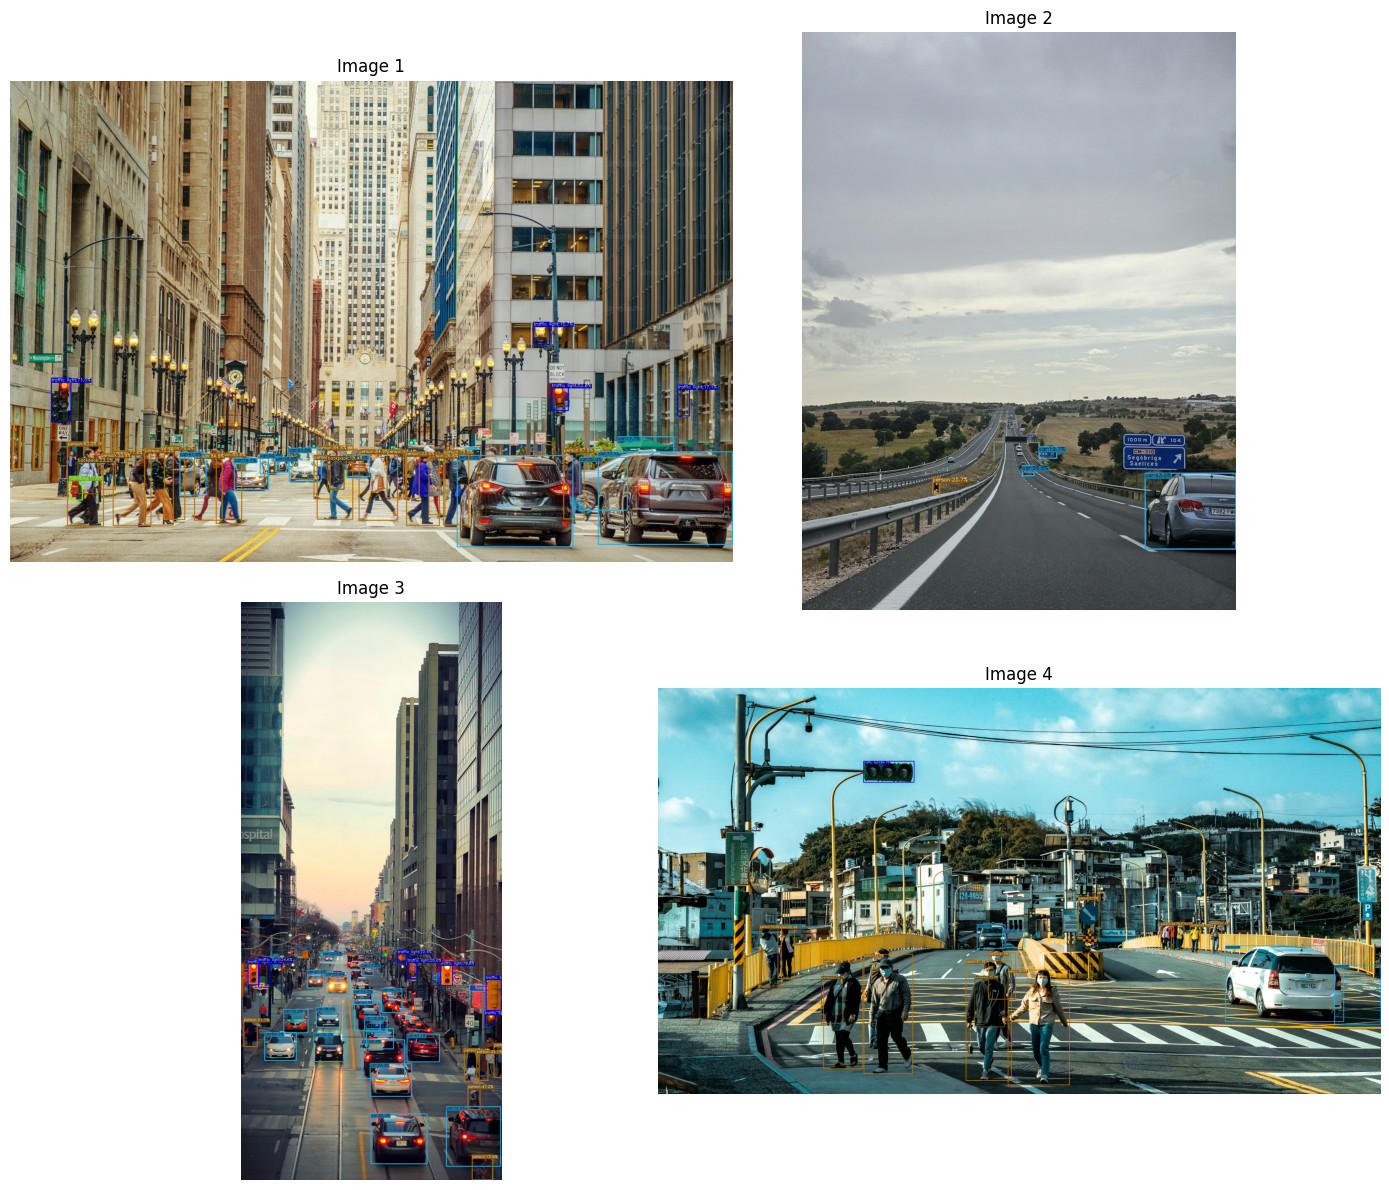

In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

output_root = Path("YOLOX_outputs")
image_files = sorted(list(output_root.glob("**/*.jpg")) + list(output_root.glob("**/*.png")))

print("Detected output images:")
for f in image_files:
    print("-", f)

plt.figure(figsize=(14, 12))
for i, f in enumerate(image_files[:4], 1):
    plt.subplot(2, 2, i)
    plt.imshow(Image.open(f))
    plt.title(f.stem.replace("_", " ").title())
    plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Download the Outputs

In [6]:
from google.colab import files

for f in image_files[:4]:
    files.download(str(f))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes for the Report

- This notebook provides an additional object detection experiment using **YOLOX-S**.
- The setup is kept simple and similar to the YOLOv7 workflow.
- These outputs can be used as supplementary comparison evidence alongside the YOLOv7 experiment.
